In [3]:
%pip install tpot joblib

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   --------------------- ------------------ 0.8/1.5 MB 4.1 MB/s eta 0:00:01
   ------------------------------------ --- 1.3/1.5 MB 4.3 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 3.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/72.0 MB 2.3 MB/s eta 0:00:32
   -------------------

  DEPRECATION: Building 'func-timeout' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'func-timeout'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  DEPRECATION: Building 'stopit' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'stopit'. Discussion can be found at https://github.com/pypa/pip/issues/6334


                age        fnlwgt  education_num  capital_gain  capital_loss  \
count  48842.000000  4.884200e+04   48842.000000  48842.000000  48842.000000   
mean      38.643585  1.896641e+05      10.078089   1079.067626     87.502314   
std       13.710510  1.056040e+05       2.570973   7452.019058    403.004552   
min       17.000000  1.228500e+04       1.000000      0.000000      0.000000   
25%       28.000000  1.175505e+05       9.000000      0.000000      0.000000   
50%       37.000000  1.781445e+05      10.000000      0.000000      0.000000   
75%       48.000000  2.376420e+05      12.000000      0.000000      0.000000   
max       90.000000  1.490400e+06      16.000000  99999.000000   4356.000000   

       hours_per_week  
count    48842.000000  
mean        40.422382  
std         12.391444  
min          1.000000  
25%         40.000000  
50%         40.000000  
75%         45.000000  
max         99.000000  
income
<=50K    0.760718
>50K     0.239282
Name: proportion, dt

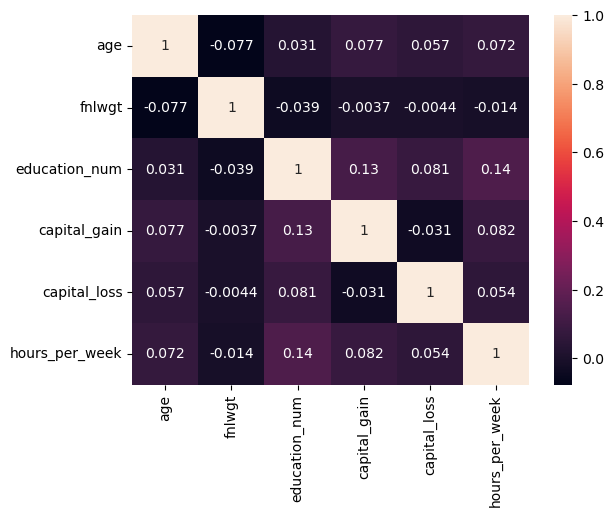

Baseline Accuracy: 0.8467208080256603
Baseline F1: 0.644169835234474
Baseline AUC: 0.7537415136528312


C:\Users\LENOVO\anaconda3\Lib\site-packages\tpot\tpot_estimator\estimator.py:458: UserWarning: Both generations and max_time_mins are set. TPOT will terminate when the first condition is met.
  warnings.warn("Both generations and max_time_mins are set. TPOT will terminate when the first condition is met.")
C:\Users\LENOVO\anaconda3\Lib\site-packages\distributed\node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 52780 instead
  warnings.warn(
Generation:  60%|████████████████████████████████████████▊                           | 3/5 [1:00:11<40:07, 1203.75s/it]
C:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


TPOT Accuracy: 0.8086398689688118
TPOT F1: 0.6876809979950992
TPOT AUC: 0.8298897600363483


['preprocessor.joblib']

In [8]:
# Install dependencies if needed
# !pip install tpot joblib

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from tpot import TPOTClassifier
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load dataset
columns = ['age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status', 'occupation', 
           'relationship', 'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income']
train_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data'
test_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.test'
train_df = pd.read_csv(train_url, names=columns, skipinitialspace=True)
test_df = pd.read_csv(test_url, names=columns, skipinitialspace=True, skiprows=1)
test_df['income'] = test_df['income'].str.replace('.', '')  # Clean test labels
df = pd.concat([train_df, test_df], ignore_index=True)

# 2. EDA
print(df.describe())
print(df['income'].value_counts(normalize=True))  # Class balance
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True)
plt.show()
# Additional plots: sns.histplot(df['age']), etc.

# 3. Preprocessing
# df.replace('?', np.nan, inplace=True)
# X = df.drop('income', axis=1)
# y = (df['income'] == '>50K').astype(int)
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# num_features = ['age', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']
# cat_features = ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country']

# num_transformer = Pipeline(steps=[
#     ('imputer', SimpleImputer(strategy='median')),
#     ('scaler', StandardScaler())
# ])
# cat_transformer = Pipeline(steps=[
#     ('imputer', SimpleImputer(strategy='most_frequent')),
#     ('onehot', OneHotEncoder(handle_unknown='ignore'))
# ])

# preprocessor = ColumnTransformer(transformers=[
#     ('num', num_transformer, num_features),
#     ('cat', cat_transformer, cat_features)
# ])

# 3. Preprocessing (Corrected Order)

# Replace '?' with NaN globally first
df.replace('?', np.nan, inplace=True)

# Separate features (X) and target (y)
X = df.drop('income', axis=1)
y = (df['income'] == '>50K').astype(int)

# --- Perform Feature Engineering on X BEFORE splitting ---

# Add net_capital
X['net_capital'] = X['capital_gain'] - X['capital_loss']
num_features.append('net_capital') # Ensure 'net_capital' is in your numerical feature list

# Drop fnlwgt
X = X.drop('fnlwgt', axis=1)

# Ensure 'fnlwgt' is removed from the numerical features list if it was ever in there initially
# (In your original code, it wasn't, so this is just a sanity check)

# --- Now split the data ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


# Define features lists again (to be safe, though they should be updated by append)
num_features = ['age', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week', 'net_capital']
cat_features = ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country']

# Preprocessing Pipelines (These remain the same)
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])

####################################################### commented the below 5 lines of code
# Feature engineering: Add net_capital
# X['net_capital'] = X['capital_gain'] - X['capital_loss']
# num_features.append('net_capital')

# # Drop fnlwgt
# X = X.drop('fnlwgt', axis=1)

# 4. Baseline
baseline_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])
baseline_pipeline.fit(X_train, y_train)
y_pred_baseline = baseline_pipeline.predict(X_test)
print('Baseline Accuracy:', accuracy_score(y_test, y_pred_baseline))
print('Baseline F1:', f1_score(y_test, y_pred_baseline))
print('Baseline AUC:', roc_auc_score(y_test, y_pred_baseline))

# 5. AutoML with TPOT (limit to 30 min)
# tpot = TPOTClassifier(generations=5, population_size=20, verbosity=2, random_state=42, n_jobs=-1)
# tpot.fit(preprocessor.fit_transform(X_train), y_train)
# y_pred_tpot = tpot.predict(preprocessor.transform(X_test))
# print('TPOT Accuracy:', accuracy_score(y_test, y_pred_tpot))
# print('TPOT F1:', f1_score(y_test, y_pred_tpot))
# print('TPOT AUC:', roc_auc_score(y_test, y_pred_tpot))

# 5. AutoML with TPOT (limit to 30 min)

# Change 'verbosity=2' to 'verbose=2'
# tpot = TPOTClassifier(generations=5, population_size=20, verbose=2, random_state=42, n_jobs=-1)
tpot = TPOTClassifier(generations=5, population_size=20, verbose=2, random_state=42, n_jobs=1)

# The fit line remains the same:
tpot.fit(preprocessor.fit_transform(X_train), y_train)
y_pred_tpot = tpot.predict(preprocessor.transform(X_test))
print('TPOT Accuracy:', accuracy_score(y_test, y_pred_tpot))
print('TPOT F1:', f1_score(y_test, y_pred_tpot))
print('TPOT AUC:', roc_auc_score(y_test, y_pred_tpot))
 
# 6. Save best model (TPOT's exported pipeline)
# tpot.export('best_pipeline.py')
# joblib.dump(preprocessor, 'preprocessor.joblib')  # Save preprocessor separately if needed

# 6. Save best model (TPOT's exported pipeline)

# Remove the line that causes the error:
# tpot.export('best_pipeline.py') 

# Instead, save the internal best pipeline directly using joblib:
best_model = tpot.fitted_pipeline_
joblib.dump(best_model, 'best_model.joblib')

joblib.dump(preprocessor, 'preprocessor.joblib')  # Save preprocessor separately
# Note: Run best_pipeline.py to get the model, then joblib.dump(model, 'best_model.joblib')